## Import require libraries

In [2]:
# Import libraries for spam detection
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

import pandas as pd
import matplotlib.pyplot as plt

# Data preprocessing and feature extraction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

## Import the models that we are going to use

In [1]:
# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Ensemble learning - Stacking classifier
from sklearn.ensemble import StackingClassifier

In [3]:
# Load the data
data = pd.read_csv("spam-email-detection.csv")
data

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
data.isna().sum()

Category    0
Message     0
dtype: int64

In [5]:
data.dtypes

Category    str
Message     str
dtype: object

In [6]:
# Convert the Category into object
data['Category'] = data['Category'].astype('object')
print(data['Category'].dtypes)

object


In [7]:
# Convert the 'spam' into 0 and 'hum' into 1
data.loc[data['Category'] == 'spam', 'Category',] = 0
data.loc[data['Category'] == 'ham', 'Category',] = 1

In [8]:
data['Category'].value_counts()

Category
1    4825
0     747
Name: count, dtype: int64

In [9]:
# Create target (X) and label (y)
X = data['Message']
y = data['Category']

In [10]:
X

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will Ì_ b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str

In [11]:
y

0       1
1       1
2       0
3       1
4       1
       ..
5567    0
5568    1
5569    1
5570    1
5571    1
Name: Category, Length: 5572, dtype: object

In [12]:
# Split the data into training and test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [13]:
print(X.shape)
print(X_train.shape)
print(y_test.shape)

(5572,)
(4457,)
(1115,)


In [14]:
# TF-IDF feature extraction:
# - min_df=1: Include all terms (even if they appear only once)
# - stop_words = 'english': Remove common English words (e.g., 'the', 'is')
# - lowercase=True: Convert all text to lowercase for consistency
feature_extraction = TfidfVectorizer(min_df = 1, stop_words = 'english', lowercase = True)

In [15]:
# Fit TF-IDF on training data and transform both training and test sets
X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

In [16]:
y_train = y_train.astype("int")
y_test = y_test.astype("int")

---

# Modelling

---

# Logistic Regression

In [17]:
# Instantiate Logistic Regression Model
lr = LogisticRegression()

# Fitting the model to training data
lr.fit(X_train_features, y_train)

# Make prediction
lr_train_pred = lr.predict(X_train_features)
lr_test_pred = lr.predict(X_test_features)

# Calculate training and testing accuracy
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)

# Calculate precision, recal and f1-score
lr_precision = precision_score(y_test, lr_test_pred)
lr_recall = recall_score(y_test, lr_test_pred)
lr_f1 = f1_score(y_test, lr_test_pred)

print("Logistic Regression Accuracy: \n")
print("Training Data Accuracy: ", lr_train_acc)
print("Testing Data Accuracy: ", lr_test_acc)

print("Precision:     :", lr_precision)
print("Recall:        :", lr_recall)
print("F1 Score       :", lr_f1)

Logistic Regression Accuracy: 

Training Data Accuracy:  0.9692618353152345
Testing Data Accuracy:  0.9524663677130045
Precision:     : 0.950592885375494
Recall:        : 0.9968911917098445
F1 Score       : 0.9731917046029337


- - -

## Decision Trees

In [18]:
# Instantiate Decision Tree Model
dtrees = DecisionTreeClassifier()

# Fitting the model to training data
dtrees.fit(X_train_features, y_train)

# Make prediction
dt_train_pred = dtrees.predict(X_train_features)
dt_test_pred = dtrees.predict(X_test_features)

# Calculate Training and Testing accuracy
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

# Calculate precision, recall and f1-score
dt_precision = precision_score(y_test, dt_test_pred)
dt_recall = recall_score(y_test, dt_test_pred)
dt_f1 = f1_score(y_test, dt_test_pred)

print("Decision Trees:\n")
print("Training Data Accuracy: ", dt_train_acc)
print("Testing Data Accuracy: ", dt_test_acc)

print("Precision             :", dt_precision)
print("Recall                :", dt_recall)
print("F1                    :", dt_f1)

Decision Trees:

Training Data Accuracy:  1.0
Testing Data Accuracy:  0.968609865470852
Precision             : 0.9764344262295082
Recall                : 0.9875647668393782
F1                    : 0.9819680577022154


---

## K Nearest Neighbors (KNN)

In [19]:
# Instantiate the K Nearest Neighbors
knn = KNeighborsClassifier()

# Fitting the model to training data
knn.fit(X_train_features, y_train)

# Make precision
knn_train_pred = knn.predict(X_train_features)
knn_test_pred = knn.predict(X_test_features)

# Calculate Training and Testing accuracy
knn_train_acc = accuracy_score(y_train, knn_train_pred)
knn_test_acc = accuracy_score(y_test, knn_test_pred)

# Calculate precision, recall and f1-score
knn_precision = precision_score(y_test, knn_test_pred)
knn_recall = recall_score(y_test, knn_test_pred)
knn_f1 = f1_score(y_test, knn_test_pred)

print("K Nearest Neighbors: \n")

print("Training Data Accuracy: ", knn_train_acc)
print("Testing Data Accuracy : ", knn_test_acc)

print("Precision:            :", knn_precision)
print("Recall:               :", knn_recall)
print("F1 Score:             :", knn_f1)

K Nearest Neighbors: 

Training Data Accuracy:  0.9158626879066637
Testing Data Accuracy :  0.9130044843049328
Precision:            : 0.908662900188324
Recall:               : 1.0
F1 Score:             : 0.9521460286137149


---

## Random Forest

In [20]:
# Instantiate The Random Forest Model
rf = RandomForestClassifier()

# Fitting the model to training data
rf.fit(X_train_features, y_train)

# Make prediction
rf_train_pred = rf.predict(X_train_features)
rf_test_pred = rf.predict(X_test_features)

# Calculate Training and Testing accuracy score
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

# Calculate precision, recall and f1-score
rf_precision = precision_score(y_test, rf_test_pred)
rf_recall = recall_score(y_test, rf_test_pred)
rf_f1 = f1_score(y_test, rf_test_pred)

print("Random Forests: \n")
print("Training Data Accuracy:", rf_train_acc)
print("Testing Data Accuracy :", rf_test_acc)

print("Precision             :", rf_precision)
print("Recall                :", rf_recall)
print("F1-Score              :", rf_f1)

Random Forests: 

Training Data Accuracy: 1.0
Testing Data Accuracy : 0.9802690582959641
Precision             : 0.9786802030456853
Recall                : 0.9989637305699481
F1-Score              : 0.9887179487179487


---

# Stacking Model
(Final Model)

In [21]:
# Define base models for stacking
estimator = [ ("lr", lr), ("dtrees", dtrees), ("knn", knn), ("rf", rf) ]

# Create stacking classifier with SVM as final meta-learner
stack = StackingClassifier(estimator, final_estimator = SVC(kernel = 'linear'))

# Train the stacking model on training data
stack.fit(X_train_features, y_train)

# Make prediction
stack_train_pred = stack.predict(X_train_features)
stack_test_pred = stack.predict(X_test_features)

# Calculate Training and Testing accuracy
stack_train_acc = accuracy_score(y_train, stack_train_pred)
stack_test_acc = accuracy_score(y_test, stack_test_pred)

# Calculate precision, recall and f1-score
stack_precision = precision_score(y_test, stack_test_pred)
stack_recall = recall_score(y_test, stack_test_pred)
stack_f1 = f1_score(y_test, stack_test_pred)

print("Stacking Classifier: \n")
print("Training data accuracy :", stack_train_acc)
print("Testing data accuracy  :", stack_test_acc)

print("Precision              :", stack_precision)
print("recall                 :", stack_recall)
print("F1 Score               :", stack_f1)

Stacking Classifier: 

Training data accuracy : 0.9995512676688355
Testing data accuracy  : 0.97847533632287
Precision              : 0.9825641025641025
recall                 : 0.9927461139896373
F1 Score               : 0.9876288659793815


---

## Metrics Visualization

In [22]:
# Create the accuracy, precision, recall and f1-score list

train_acc_list = {
    "LR": lr_train_acc,
    "DT": dt_train_acc,
    "KNN": knn_train_acc,
    "RF": rf_train_acc,
    "STACK": stack_train_acc
}

test_acc_list = {
    "LR": lr_test_acc,
    "DT": dt_test_acc,
    "KNN": knn_test_acc,
    "RF": rf_test_acc,
    "STACK": stack_test_acc
}

precision_list = {
    "LR": lr_precision,
    "DT": dt_precision,
    "KNN": knn_precision,
    "RF": rf_precision,
    "STACK": stack_precision
}

recall_list = {
    "LR": lr_recall,
    "DT": dt_recall,
    "KNN": knn_recall,
    "RF": rf_recall,
    "STACK": stack_recall
}

f1_list = {
    "LR": lr_f1,
    "DT": dt_f1,
    "KNN": knn_f1,
    "RF": rf_f1,
    "STACK": stack_f1
}

In [23]:
a1 = pd.DataFrame.from_dict(train_acc_list, orient = "index", columns = ["Training Accuracy"])
a2 = pd.DataFrame.from_dict(test_acc_list, orient = "index", columns = ["Testing Accuracy"])
a3 = pd.DataFrame.from_dict(precision_list, orient = "index", columns = ["Precision Score"])
a4 = pd.DataFrame.from_dict(recall_list, orient = "index", columns = ["Recall Score"])
a5 = pd.DataFrame.from_dict(f1_list, orient = "index", columns = ["F1 Score"])

org = pd.concat([a1, a2, a3, a4, a5], axis = 1)
org

,Training Accuracy,Testing Accuracy,Precision Score,Recall Score,F1 Score
LR,0.969262,0.952466,0.950593,0.996891,0.973192
DT,1.000000,0.968610,0.976434,0.987565,0.981968
KNN,0.915863,0.913004,0.908663,1.000000,0.952146
RF,1.000000,0.980269,0.978680,0.998964,0.988718
STACK,0.999551,0.978475,0.982564,0.992746,0.987629


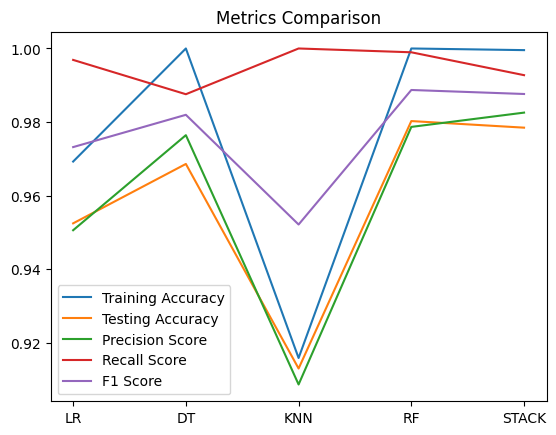

In [24]:
alg = ["LR", "DT", "KNN", "RF", "STACK"]
plt.plot(alg, a1)
plt.plot(alg, a2)
plt.plot(alg, a3)
plt.plot(alg, a4)
plt.plot(alg, a5)

legend = ["Training Accuracy", "Testing Accuracy", "Precision Score", "Recall Score", "F1 Score"]
plt.title("Metrics Comparison")
plt.legend(legend)
plt.show()

In [25]:
input_mail = ["CONGRATULATIONS! You've won a $1000 Amazon gift card! Click here to claim your prize now: http://bit.ly/win-now"]

input_mail_features = feature_extraction.transform(input_mail)

prediction = stack.predict(input_mail_features)

if(prediction == 0):
    print("SPAM MAIL")
else:
    print("HAM MAIL")

SPAM MAIL


In [26]:
input_mail = ["Hello Karo, How are you?"]

input_mail_features = feature_extraction.transform(input_mail)

prediction = stack.predict(input_mail_features)

if(prediction == 0):
    print("SPAM MAIL")
else:
    print("HAM MAIL")

HAM MAIL
